## 1. XGBoost model

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ==============================
# 1. SETTINGS
# ==============================
file = "Combine shuffle data.xlsx"
sheets = ["d1", "d2", "d3", "d4", "d5"]

features = ['CRS', 'Thrust', 'Torque', 'RMR', 'PRchd', 
            'Weathering', 'Rock Strength']
target = 'PRnet'

# ==============================
# 2. METRIC FUNCTION
# ==============================
def evaluate_model(Y_true, Y_pred):
    r2 = float(r2_score(Y_true, Y_pred))
    mae = float(mean_absolute_error(Y_true, Y_pred))
    rmse = float(np.sqrt(mean_squared_error(Y_true, Y_pred)))
    mape = float(np.mean(np.abs((Y_true - Y_pred) / (Y_true + 1e-10))) * 100)
    return {'R2': round(r2,3), 'MAE': round(mae,3), 
            'RMSE': round(rmse,3), 'MAPE': round(mape,3)}

# ==============================
# 3. LOAD ALL SHEETS
# ==============================
sheet_data = {name: pd.read_excel(file, sheet_name=name) for name in sheets}

# ==============================
# 4. RUN 5-FOLD CV
# ==============================
train_metrics_list = []
test_metrics_list = []

for i, test_sheet in enumerate(sheets, 1):
    # Training = all sheets except test_sheet
    train_sheets = [s for s in sheets if s != test_sheet]
    df_train = pd.concat([sheet_data[s] for s in train_sheets], ignore_index=True)
    df_test  = sheet_data[test_sheet].copy()

    # Encode categorical columns
    for col in ["Weathering", "Rock Strength"]:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col] = le.transform(df_test[col])

    # Scale features
    scaler = RobustScaler()
    X_train = scaler.fit_transform(df_train[features])
    X_test  = scaler.transform(df_test[features])
    Y_train = df_train[target]
    Y_test  = df_test[target]

    # Train model
    model = XGBRegressor(
        colsample_bytree=1, gamma=5, learning_rate=0.1,
        max_depth=7, n_estimators=100, subsample=0.8, random_state=42
    )
    model.fit(X_train, Y_train)

    # Predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred  = model.predict(X_test)

    # Evaluate
    train_metrics = evaluate_model(Y_train, Y_train_pred)
    test_metrics  = evaluate_model(Y_test, Y_test_pred)

    # Add fold info
    train_metrics["Fold"] = i
    test_metrics["Fold"]  = i

    train_metrics_list.append(train_metrics)
    test_metrics_list.append(test_metrics)

# ==============================
# 5. CREATE DATAFRAMES
# ==============================
train_df = pd.DataFrame(train_metrics_list).set_index("Fold")
test_df  = pd.DataFrame(test_metrics_list).set_index("Fold")

# ==============================
# 6. PRINT METRICS
# ==============================
print("\n🔁 5-Fold CV Metrics (Training):")
print(train_df)
print("\n📊 Average Training Metrics:")
print(train_df.mean().round(3))

print("\n🔁 5-Fold CV Metrics (Test):")
print(test_df)
print("\n📊 Average Test Metrics:")
print(test_df.mean().round(3))


🔁 5-Fold CV Metrics (Training):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.984  1.148  2.071  1.844
2     0.985  1.119  2.010  1.786
3     0.984  1.140  2.062  1.826
4     0.984  1.127  2.041  1.809
5     0.985  1.125  2.025  1.803

📊 Average Training Metrics:
R2      0.984
MAE     1.132
RMSE    2.042
MAPE    1.814
dtype: float64

🔁 5-Fold CV Metrics (Test):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.969  1.433  2.868  2.292
2     0.962  1.560  3.167  2.585
3     0.966  1.498  3.054  2.417
4     0.965  1.494  3.022  2.390
5     0.964  1.512  3.100  2.466

📊 Average Test Metrics:
R2      0.965
MAE     1.499
RMSE    3.042
MAPE    2.430
dtype: float64


## 1.1 Confidence interval results in XGBoost model

In [3]:
import numpy as np
import scipy.stats as stats
results_df = test_df.copy()
def t_based_ci(metric_values, alpha=0.05):
    metric_values = np.asarray(metric_values)
    n = len(metric_values)
    mean_val = metric_values.mean()
    std_val = metric_values.std(ddof=1)
    sem = std_val / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    moe = t_crit * sem
    return mean_val, mean_val - moe, mean_val + moe, moe

for col in ['R2','MAE', 'RMSE', 'MAPE']:
    mean_v, lo, hi, moe = t_based_ci(results_df[col].values)
    print(f"{col}: mean={mean_v:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}] (±{moe:.4f})")

R2: mean=0.9652, 95% CI=[0.9620, 0.9684] (±0.0032)
MAE: mean=1.4994, 95% CI=[1.4429, 1.5559] (±0.0565)
RMSE: mean=3.0422, 95% CI=[2.9036, 3.1808] (±0.1386)
MAPE: mean=2.4300, 95% CI=[2.2967, 2.5633] (±0.1333)


## 1.2 Statistical Significance of XGBoost

In [4]:
import scipy.stats as stats

# Extract R² scores from test folds
r2_scores = test_df['R2'].values

# One-sample t-test: Is mean R² significantly greater than 0?
t_statistic, p_value_two_tailed = stats.ttest_1samp(r2_scores, 0)

# For "greater than 0" significance, use one-tailed test
p_value_one_tailed = p_value_two_tailed / 2

# Determine significance level (stars)
if p_value_one_tailed < 0.001:
    significance = "*** (p < 0.001)"
elif p_value_one_tailed < 0.01:
    significance = "** (p < 0.01)"
elif p_value_one_tailed < 0.05:
    significance = "* (p < 0.05)"
else:
    significance = "ns (not significant)"

print("\n===== Statistical Significance Test =====")
print(f"T-statistic: {t_statistic:.4f}")
print(f"One-tailed p-value: {p_value_one_tailed:.5f}")
print(f"Significance: {significance}")


===== Statistical Significance Test =====
T-statistic: 833.8058
One-tailed p-value: 0.00000
Significance: *** (p < 0.001)


## 2. Random forest model

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# ==============================
# 1. SETTINGS
# ==============================
file = "Combine shuffle data.xlsx"
sheets = ["d1", "d2", "d3", "d4", "d5"]

features = ['CRS', 'Thrust', 'Torque', 'RMR', 'PRchd', 
            'Weathering', 'Rock Strength']
target = 'PRnet'

# ==============================
# 2. METRIC FUNCTION
# ==============================
def evaluate_model(Y_true, Y_pred):
    r2 = float(r2_score(Y_true, Y_pred))
    mae = float(mean_absolute_error(Y_true, Y_pred))
    rmse = float(np.sqrt(mean_squared_error(Y_true, Y_pred)))
    mape = float(np.mean(np.abs((Y_true - Y_pred) / (Y_true + 1e-10))) * 100)
    return {'R2': round(r2,3), 'MAE': round(mae,3), 
            'RMSE': round(rmse,3), 'MAPE': round(mape,3)}

# ==============================
# 3. LOAD ALL SHEETS
# ==============================
sheet_data = {name: pd.read_excel(file, sheet_name=name) for name in sheets}

# ==============================
# 4. RUN 5-FOLD CV
# ==============================
train_metrics_list = []
test_metrics_list = []

for i, test_sheet in enumerate(sheets, 1):
    # Training = all sheets except test_sheet
    train_sheets = [s for s in sheets if s != test_sheet]
    df_train = pd.concat([sheet_data[s] for s in train_sheets], ignore_index=True)
    df_test  = sheet_data[test_sheet].copy()

    # Encode categorical columns
    for col in ["Weathering", "Rock Strength"]:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col] = le.transform(df_test[col])

    # Scale features
    scaler = RobustScaler()
    X_train = scaler.fit_transform(df_train[features])
    X_test  = scaler.transform(df_test[features])
    Y_train = df_train[target]
    Y_test  = df_test[target]

    # Train model
    model = RandomForestRegressor(
    n_estimators=200,
    max_depth=30,
    max_features='log2',
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
    )
    model.fit(X_train, Y_train)

    # Predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred  = model.predict(X_test)

    # Evaluate
    train_metrics = evaluate_model(Y_train, Y_train_pred)
    test_metrics  = evaluate_model(Y_test, Y_test_pred)

    # Add fold info
    train_metrics["Fold"] = i
    test_metrics["Fold"]  = i

    train_metrics_list.append(train_metrics)
    test_metrics_list.append(test_metrics)

# ==============================
# 5. CREATE DATAFRAMES
# ==============================
train_df = pd.DataFrame(train_metrics_list).set_index("Fold")
test_df  = pd.DataFrame(test_metrics_list).set_index("Fold")

# ==============================
# 6. PRINT METRICS
# ==============================
print("\n🔁 5-Fold CV Metrics (Training):")
print(train_df)
print("\n📊 Average Training Metrics:")
print(train_df.mean().round(3))

print("\n🔁 5-Fold CV Metrics (Test):")
print(test_df)
print("\n📊 Average Test Metrics:")
print(test_df.mean().round(3))


🔁 5-Fold CV Metrics (Training):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.989  0.959  1.742  1.606
2     0.989  0.937  1.690  1.556
3     0.989  0.945  1.707  1.583
4     0.989  0.950  1.728  1.589
5     0.989  0.946  1.709  1.574

📊 Average Training Metrics:
R2      0.989
MAE     0.947
RMSE    1.715
MAPE    1.582
dtype: float64

🔁 5-Fold CV Metrics (Test):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.967  1.654  2.976  2.743
2     0.960  1.743  3.242  3.007
3     0.963  1.769  3.182  2.955
4     0.963  1.716  3.092  2.844
5     0.959  1.769  3.283  2.982

📊 Average Test Metrics:
R2      0.962
MAE     1.730
RMSE    3.155
MAPE    2.906
dtype: float64


## 2.1 Confidence interval results in RF model

In [6]:
import numpy as np
import scipy.stats as stats
results_df = test_df.copy()
def t_based_ci(metric_values, alpha=0.05):
    metric_values = np.asarray(metric_values)
    n = len(metric_values)
    mean_val = metric_values.mean()
    std_val = metric_values.std(ddof=1)
    sem = std_val / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    moe = t_crit * sem
    return mean_val, mean_val - moe, mean_val + moe, moe

for col in ['R2', 'MAE', 'RMSE', 'MAPE']:
    mean_v, lo, hi, moe = t_based_ci(results_df[col].values)
    print(f"{col}: mean={mean_v:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}] (±{moe:.4f})")

R2: mean=0.9624, 95% CI=[0.9585, 0.9663] (±0.0039)
MAE: mean=1.7302, 95% CI=[1.6707, 1.7897] (±0.0595)
RMSE: mean=3.1550, 95% CI=[3.0021, 3.3079] (±0.1529)
MAPE: mean=2.9062, 95% CI=[2.7691, 3.0433] (±0.1371)


## 2.2 Statistical Significance of RF

In [7]:
import scipy.stats as stats

# Extract R² scores from test folds
r2_scores = test_df['R2'].values

# One-sample t-test: Is mean R² significantly greater than 0?
t_statistic, p_value_two_tailed = stats.ttest_1samp(r2_scores, 0)

# For "greater than 0" significance, use one-tailed test
p_value_one_tailed = p_value_two_tailed / 2

# Determine significance level (stars)
if p_value_one_tailed < 0.001:
    significance = "*** (p < 0.001)"
elif p_value_one_tailed < 0.01:
    significance = "** (p < 0.01)"
elif p_value_one_tailed < 0.05:
    significance = "* (p < 0.05)"
else:
    significance = "ns (not significant)"

print("\n===== Statistical Significance Test =====")
print(f"T-statistic: {t_statistic:.4f}")
print(f"One-tailed p-value: {p_value_one_tailed:.5f}")
print(f"Significance: {significance}")


===== Statistical Significance Test =====
T-statistic: 687.4286
One-tailed p-value: 0.00000
Significance: *** (p < 0.001)


## 3. Bagging model

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# ==============================
# 1. SETTINGS
# ==============================
file = "Combine shuffle data.xlsx"
sheets = ["d1", "d2", "d3", "d4", "d5"]

features = ['CRS', 'Thrust', 'Torque', 'RMR', 'PRchd', 
            'Weathering', 'Rock Strength']
target = 'PRnet'

# ==============================
# 2. METRIC FUNCTION
# ==============================
def evaluate_model(Y_true, Y_pred):
    r2 = float(r2_score(Y_true, Y_pred))
    mae = float(mean_absolute_error(Y_true, Y_pred))
    rmse = float(np.sqrt(mean_squared_error(Y_true, Y_pred)))
    mape = float(np.mean(np.abs((Y_true - Y_pred) / (Y_true + 1e-10))) * 100)
    return {'R2': round(r2,3), 'MAE': round(mae,3), 
            'RMSE': round(rmse,3), 'MAPE': round(mape,3)}

# ==============================
# 3. LOAD ALL SHEETS
# ==============================
sheet_data = {name: pd.read_excel(file, sheet_name=name) for name in sheets}

# ==============================
# 4. RUN 5-FOLD CV
# ==============================
train_metrics_list = []
test_metrics_list = []

for i, test_sheet in enumerate(sheets, 1):
    # Training = all sheets except test_sheet
    train_sheets = [s for s in sheets if s != test_sheet]
    df_train = pd.concat([sheet_data[s] for s in train_sheets], ignore_index=True)
    df_test  = sheet_data[test_sheet].copy()

    # Encode categorical columns
    for col in ["Weathering", "Rock Strength"]:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col] = le.transform(df_test[col])

    # Scale features
    scaler = RobustScaler()
    X_train = scaler.fit_transform(df_train[features])
    X_test  = scaler.transform(df_test[features])
    Y_train = df_train[target]
    Y_test  = df_test[target]

    # Train model
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=100,
        max_samples=0.5,
        max_features=1.0,
        bootstrap=True,
        bootstrap_features=False,
        random_state=42
    )
    model.fit(X_train, Y_train)

    # Predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred  = model.predict(X_test)

    # Evaluate
    train_metrics = evaluate_model(Y_train, Y_train_pred)
    test_metrics  = evaluate_model(Y_test, Y_test_pred)

    # Add fold info
    train_metrics["Fold"] = i
    test_metrics["Fold"]  = i

    train_metrics_list.append(train_metrics)
    test_metrics_list.append(test_metrics)

# ==============================
# 5. CREATE DATAFRAMES
# ==============================
train_df = pd.DataFrame(train_metrics_list).set_index("Fold")
test_df  = pd.DataFrame(test_metrics_list).set_index("Fold")

# ==============================
# 6. PRINT METRICS
# ==============================
print("\n🔁 5-Fold CV Metrics (Training):")
print(train_df)
print("\n📊 Average Training Metrics:")
print(train_df.mean().round(3))

print("\n🔁 5-Fold CV Metrics (Test):")
print(test_df)
print("\n📊 Average Test Metrics:")
print(test_df.mean().round(3))


🔁 5-Fold CV Metrics (Training):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.986  0.924  1.908  1.501
2     0.987  0.900  1.845  1.445
3     0.987  0.911  1.872  1.470
4     0.986  0.911  1.899  1.469
5     0.987  0.906  1.867  1.463

📊 Average Training Metrics:
R2      0.987
MAE     0.910
RMSE    1.878
MAPE    1.470
dtype: float64

🔁 5-Fold CV Metrics (Test):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.968  1.441  2.926  2.304
2     0.961  1.543  3.220  2.528
3     0.964  1.487  3.103  2.385
4     0.963  1.489  3.076  2.388
5     0.962  1.517  3.178  2.458

📊 Average Test Metrics:
R2      0.964
MAE     1.495
RMSE    3.101
MAPE    2.413
dtype: float64


## 3.1 Confidence interval results in RF model

In [9]:
import numpy as np
import scipy.stats as stats
results_df = test_df.copy()
def t_based_ci(metric_values, alpha=0.05):
    metric_values = np.asarray(metric_values)
    n = len(metric_values)
    mean_val = metric_values.mean()
    std_val = metric_values.std(ddof=1)
    sem = std_val / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    moe = t_crit * sem
    return mean_val, mean_val - moe, mean_val + moe, moe

for col in ['R2', 'MAE', 'RMSE', 'MAPE']:
    mean_v, lo, hi, moe = t_based_ci(results_df[col].values)
    print(f"{col}: mean={mean_v:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}] (±{moe:.4f})")

R2: mean=0.9636, 95% CI=[0.9602, 0.9670] (±0.0034)
MAE: mean=1.4954, 95% CI=[1.4481, 1.5427] (±0.0473)
RMSE: mean=3.1006, 95% CI=[2.9599, 3.2413] (±0.1407)
MAPE: mean=2.4126, 95% CI=[2.3077, 2.5175] (±0.1049)


## 3.2 Statistical Significance

In [10]:
import scipy.stats as stats

# Extract R² scores from test folds
r2_scores = test_df['R2'].values

# One-sample t-test: Is mean R² significantly greater than 0?
t_statistic, p_value_two_tailed = stats.ttest_1samp(r2_scores, 0)

# For "greater than 0" significance, use one-tailed test
p_value_one_tailed = p_value_two_tailed / 2

# Determine significance level (stars)
if p_value_one_tailed < 0.001:
    significance = "*** (p < 0.001)"
elif p_value_one_tailed < 0.01:
    significance = "** (p < 0.01)"
elif p_value_one_tailed < 0.05:
    significance = "* (p < 0.05)"
else:
    significance = "ns (not significant)"

print("\n===== Statistical Significance Test =====")
print(f"T-statistic: {t_statistic:.4f}")
print(f"One-tailed p-value: {p_value_one_tailed:.5f}")
print(f"Significance: {significance}")


===== Statistical Significance Test =====
T-statistic: 797.4810
One-tailed p-value: 0.00000
Significance: *** (p < 0.001)


## 4. Stacking model

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# ==============================
# 1. SETTINGS
# ==============================
file = "Combine shuffle data.xlsx"
sheets = ["d1", "d2", "d3", "d4", "d5"]

features = ['CRS', 'Thrust', 'Torque', 'RMR', 'PRchd', 
            'Weathering', 'Rock Strength']
target = 'PRnet'

# ==============================
# 2. METRIC FUNCTION
# ==============================
def evaluate_model(Y_true, Y_pred):
    r2 = float(r2_score(Y_true, Y_pred))
    mae = float(mean_absolute_error(Y_true, Y_pred))
    rmse = float(np.sqrt(mean_squared_error(Y_true, Y_pred)))
    mape = float(np.mean(np.abs((Y_true - Y_pred) / (Y_true + 1e-10))) * 100)
    return {'R2': round(r2,3), 'MAE': round(mae,3), 
            'RMSE': round(rmse,3), 'MAPE': round(mape,3)}

# ==============================
# 3. LOAD ALL SHEETS
# ==============================
sheet_data = {name: pd.read_excel(file, sheet_name=name) for name in sheets}

# ==============================
# 4. DEFINE STACKING MODEL
# ==============================
# Base models (Bagging removed for compatibility)
base_models = [
    ('SVR', SVR(C=50.0, gamma='scale', kernel='rbf')),
    ('DT', DecisionTreeRegressor(
        criterion='absolute_error',
        max_depth=10,
        min_samples_leaf=6,
        min_samples_split=2
    )),
    ('RF', RandomForestRegressor(
        random_state=42,
        max_depth=30,
        max_features='log2',
        min_samples_leaf=1,
        min_samples_split=5,
        n_estimators=200
    )),
    ('KNN', KNeighborsRegressor(
        n_neighbors=5,
        p=1,
        weights='distance'
    )),
    ('XGB', XGBRegressor(
        colsample_bytree=1,
        gamma=5,
        learning_rate=0.1,
        max_depth=7,
        n_estimators=100,
        subsample=0.8,
        random_state=42,
        verbosity=0
    ))
]

# Meta-model
meta_regressor = RandomForestRegressor(
    random_state=42,
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=200
)

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_regressor,
    passthrough=False,
    n_jobs=-1
)

# ==============================
# 5. RUN 5-FOLD CV (LEAVE-ONE-SHEET-OUT)
# ==============================
train_metrics_list = []
test_metrics_list = []

for i, test_sheet in enumerate(sheets, 1):
    # Training = all sheets except test_sheet
    train_sheets = [s for s in sheets if s != test_sheet]
    df_train = pd.concat([sheet_data[s] for s in train_sheets], ignore_index=True)
    df_test  = sheet_data[test_sheet].copy()

    # Encode categorical columns
    for col in ["Weathering", "Rock Strength"]:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col] = le.transform(df_test[col])

    # Scale features
    scaler = RobustScaler()
    X_train = scaler.fit_transform(df_train[features])
    X_test  = scaler.transform(df_test[features])
    Y_train = df_train[target]
    Y_test  = df_test[target]

    # Train stacking model
    stacking_model.fit(X_train, Y_train)

    # Predictions
    Y_train_pred = stacking_model.predict(X_train)
    Y_test_pred  = stacking_model.predict(X_test)

    # Evaluate
    train_metrics = evaluate_model(Y_train, Y_train_pred)
    test_metrics  = evaluate_model(Y_test, Y_test_pred)

    # Add fold info
    train_metrics["Fold"] = i
    test_metrics["Fold"]  = i

    train_metrics_list.append(train_metrics)
    test_metrics_list.append(test_metrics)

# ==============================
# 6. CREATE DATAFRAMES
# ==============================
train_df = pd.DataFrame(train_metrics_list).set_index("Fold")
test_df  = pd.DataFrame(test_metrics_list).set_index("Fold")

# ==============================
# 7. PRINT METRICS
# ==============================
print("\n🔁 5-Fold CV Metrics (Training):")
print(train_df)
print("\n📊 Average Training Metrics:")
print(train_df.mean().round(3))

print("\n🔁 5-Fold CV Metrics (Test):")
print(test_df)
print("\n📊 Average Test Metrics:")
print(test_df.mean().round(3))


🔁 5-Fold CV Metrics (Training):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.986  0.974  1.919  1.562
2     0.987  0.969  1.879  1.547
3     0.986  0.991  1.927  1.588
4     0.986  0.999  1.957  1.596
5     0.986  0.982  1.927  1.573

📊 Average Training Metrics:
R2      0.986
MAE     0.983
RMSE    1.922
MAPE    1.573
dtype: float64

🔁 5-Fold CV Metrics (Test):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.970  1.378  2.811  2.186
2     0.963  1.500  3.121  2.459
3     0.965  1.478  3.067  2.351
4     0.965  1.477  3.000  2.340
5     0.964  1.486  3.107  2.419

📊 Average Test Metrics:
R2      0.965
MAE     1.464
RMSE    3.021
MAPE    2.351
dtype: float64


## 4.1 Confidence interval results in Stacking model

In [7]:
import numpy as np
import scipy.stats as stats
results_df = test_df.copy()
def t_based_ci(metric_values, alpha=0.05):
    metric_values = np.asarray(metric_values)
    n = len(metric_values)
    mean_val = metric_values.mean()
    std_val = metric_values.std(ddof=1)
    sem = std_val / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    moe = t_crit * sem
    return mean_val, mean_val - moe, mean_val + moe, moe

for col in ['R2', 'MAE', 'RMSE', 'MAPE']:
    mean_v, lo, hi, moe = t_based_ci(results_df[col].values)
    print(f"{col}: mean={mean_v:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}] (±{moe:.4f})")

R2: mean=0.9654, 95% CI=[0.9620, 0.9688] (±0.0034)
MAE: mean=1.4638, 95% CI=[1.4032, 1.5244] (±0.0606)
RMSE: mean=3.0212, 95% CI=[2.8641, 3.1783] (±0.1571)
MAPE: mean=2.3510, 95% CI=[2.2213, 2.4807] (±0.1297)


## 5. ANN Model

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# 1. SETTINGS
# ==============================
file = "Combine shuffle data.xlsx"
sheets = ["d1", "d2", "d3", "d4", "d5"]

features = ['CRS', 'Thrust', 'Torque', 'RMR', 'PRchd', 
            'Weathering', 'Rock Strength']
target = 'PRnet'

# ==============================
# 2. METRIC FUNCTION
# ==============================
def evaluate_model(Y_true, Y_pred):
    r2 = float(r2_score(Y_true, Y_pred))
    mae = float(mean_absolute_error(Y_true, Y_pred))
    rmse = float(np.sqrt(mean_squared_error(Y_true, Y_pred)))
    mape = float(np.mean(np.abs((Y_true - Y_pred) / (Y_true + 1e-10))) * 100)
    return {'R2': round(r2,3), 'MAE': round(mae,3), 
            'RMSE': round(rmse,3), 'MAPE': round(mape,3)}

# ==============================
# 3. LOAD ALL SHEETS
# ==============================
sheet_data = {name: pd.read_excel(file, sheet_name=name) for name in sheets}

# ==============================
# 4. DEFINE ANN MODEL FUNCTION
# ==============================
def create_optimal_model(input_dim):
    model = Sequential([
        Dense(352, activation='relu', kernel_initializer='glorot_uniform', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.1),
        Dense(1, activation='relu', kernel_initializer='he_normal')
    ])
    adam_optimizer = Adam(learning_rate=0.001)
    model.compile(
        optimizer=adam_optimizer,
        loss='mean_absolute_error',
        metrics=['mean_absolute_error', 'mean_squared_error']
    )
    return model

# ==============================
# 5. RUN 5-FOLD CV
# ==============================
train_metrics_list = []
test_metrics_list = []

for i, test_sheet in enumerate(sheets, 1):
    # Training = all sheets except test_sheet
    train_sheets = [s for s in sheets if s != test_sheet]
    df_train = pd.concat([sheet_data[s] for s in train_sheets], ignore_index=True)
    df_test  = sheet_data[test_sheet].copy()

    # Encode categorical columns
    for col in ["Weathering", "Rock Strength"]:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col] = le.transform(df_test[col])

    # Scale features
    scaler = RobustScaler()
    X_train = scaler.fit_transform(df_train[features])
    X_test  = scaler.transform(df_test[features])
    Y_train = df_train[target].values
    Y_test  = df_test[target].values

    # Create ANN model
    model = create_optimal_model(input_dim=X_train.shape[1])
    
    # EarlyStopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train ANN
    model.fit(
        X_train, Y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.1,
        verbose=0,
        callbacks=[early_stop]
    )

    # Predictions
    Y_train_pred = model.predict(X_train).flatten()
    Y_test_pred  = model.predict(X_test).flatten()

    # Evaluate
    train_metrics = evaluate_model(Y_train, Y_train_pred)
    test_metrics  = evaluate_model(Y_test, Y_test_pred)

    # Add fold info
    train_metrics["Fold"] = i
    test_metrics["Fold"]  = i

    train_metrics_list.append(train_metrics)
    test_metrics_list.append(test_metrics)

# ==============================
# 6. CREATE DATAFRAMES & PRINT METRICS
# ==============================
train_df = pd.DataFrame(train_metrics_list).set_index("Fold")
test_df  = pd.DataFrame(test_metrics_list).set_index("Fold")

print("\n🔁 5-Fold CV Metrics (Training):")
print(train_df)
print("\n📊 Average Training Metrics:")
print(train_df.mean().round(3))

print("\n🔁 5-Fold CV Metrics (Test):")
print(test_df)
print("\n📊 Average Test Metrics:")
print(test_df.mean().round(3))

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

🔁 5-Fold CV Metrics (Training):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.959  1.498  3.295  2.463
2     0.962  1.495  3.190  2.378
3     0.959  1.545  3.274  2.545
4     0.960  1.521  3.267  2.482
5     0.961  1.534  3.229  2.468

📊 Average Training Metrics:
R2      0.960
MAE     1.519
RMSE    3.251
MAPE    2.467
dtype: float64

🔁 5-Fold CV Metrics (Test):
         R2    MAE   RMSE   MAPE
Fold                            
1     0.965  1.399  3.039  2.268
2     0.958  1.555  3.316  2.542
3     0.959  1.564  3.332  2.592
4     0.956  1.561  3.360  2.522
5     0.960  1.542  3.265  2.472

📊 Average Test Metrics:
R2      0.960
MAE     1.524
RMSE    3.262
MAPE    2.479
dtype: float64


## 5.1 Confidence interval results in ANN model

In [15]:
import numpy as np
import scipy.stats as stats
results_df = test_df.copy()
def t_based_ci(metric_values, alpha=0.05):
    metric_values = np.asarray(metric_values)
    n = len(metric_values)
    mean_val = metric_values.mean()
    std_val = metric_values.std(ddof=1)
    sem = std_val / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    moe = t_crit * sem
    return mean_val, mean_val - moe, mean_val + moe, moe

for col in ['R2', 'MAE', 'RMSE', 'MAPE']:
    mean_v, lo, hi, moe = t_based_ci(results_df[col].values)
    print(f"{col}: mean={mean_v:.4f}, 95% CI=[{lo:.4f}, {hi:.4f}] (±{moe:.4f})")

R2: mean=0.9596, 95% CI=[0.9554, 0.9638] (±0.0042)
MAE: mean=1.5242, 95% CI=[1.4367, 1.6117] (±0.0875)
RMSE: mean=3.2624, 95% CI=[3.1015, 3.4233] (±0.1609)
MAPE: mean=2.4792, 95% CI=[2.3232, 2.6352] (±0.1560)


## 5.2 Statistical Significance

In [16]:
import scipy.stats as stats

# Extract R² scores from test folds
r2_scores = test_df['R2'].values

# One-sample t-test: Is mean R² significantly greater than 0?
t_statistic, p_value_two_tailed = stats.ttest_1samp(r2_scores, 0)

# For "greater than 0" significance, use one-tailed test
p_value_one_tailed = p_value_two_tailed / 2

# Determine significance level (stars)
if p_value_one_tailed < 0.001:
    significance = "*** (p < 0.001)"
elif p_value_one_tailed < 0.01:
    significance = "** (p < 0.01)"
elif p_value_one_tailed < 0.05:
    significance = "* (p < 0.05)"
else:
    significance = "ns (not significant)"

print("\n===== Statistical Significance Test =====")
print(f"T-statistic: {t_statistic:.4f}")
print(f"One-tailed p-value: {p_value_one_tailed:.5f}")
print(f"Significance: {significance}")


===== Statistical Significance Test =====
T-statistic: 638.3164
One-tailed p-value: 0.00000
Significance: *** (p < 0.001)


## Model Performance Comparison for R2

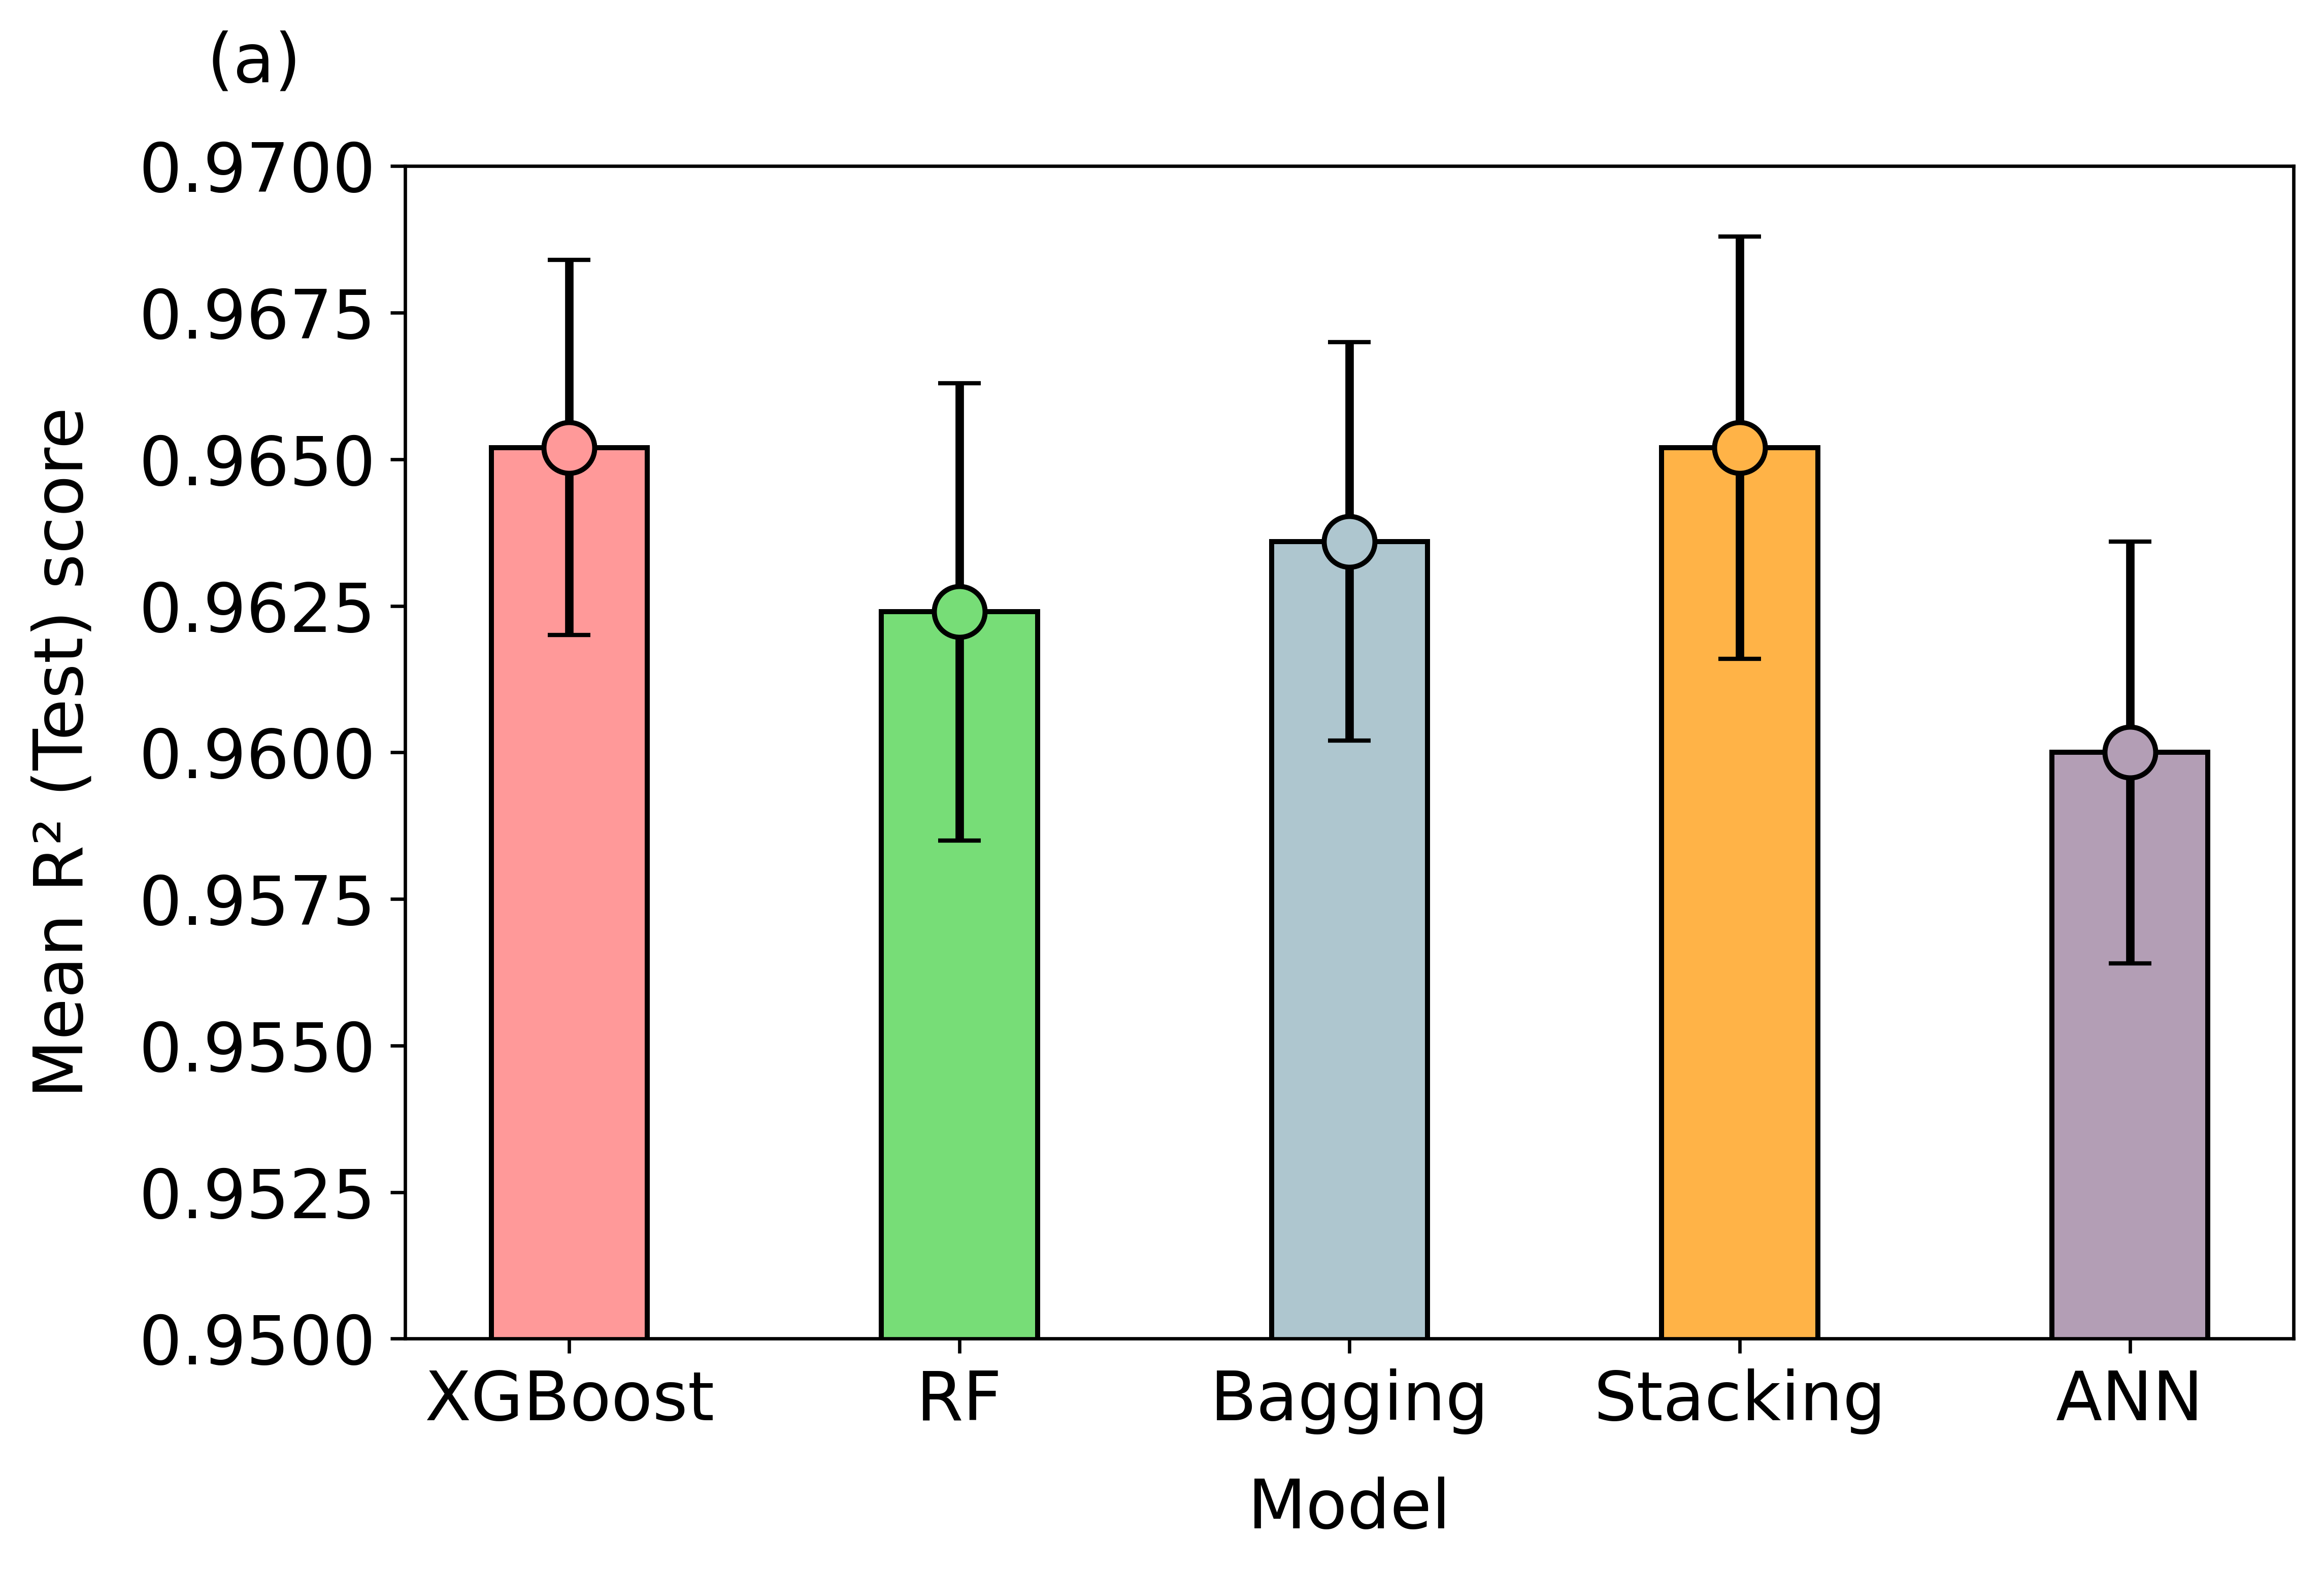

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file
file_path = 'confidence interval.xlsx'
df = pd.read_excel(file_path)

# Calculate asymmetric error bars
yerr_lower = df['Mean R2 Score'] - df['Lower R2 Score']
yerr_upper = df['Upper R2 Score'] - df['Mean R2 Score']

# Define colors for each model (for bars)
bar_colors = ["#FF9999","#77DD77", "#AEC6CF", "#FFB347", "#B39EB5"]

plt.figure(figsize=(8,5), dpi=600)

# ---- BAR PLOT ----
bars = plt.bar(
    df['Model'],
    df['Mean R2 Score'],
    width=0.4,
    color=bar_colors,        # <-- bars colored by model
    edgecolor='black',
    linewidth=1.2,
    zorder=1
)

# ---- ERROR BARS + CIRCLE MARKERS ----
for i, model in enumerate(df['Model']):
    # Error bars (black)
    plt.errorbar(
        model,
        df['Mean R2 Score'][i],
        yerr=[[yerr_lower[i]], [yerr_upper[i]]],
        fmt='none',
        capsize=5,
        ecolor='black',          # <-- error bar color black
        linewidth=2,
        zorder=3
    )

    # Circle marker filled with same color as bar
    plt.plot(
        model,
        df['Mean R2 Score'][i],
        marker='o',
        markersize=12,
        markerfacecolor=bar_colors[i],  # same color as bar
        markeredgecolor='black',
        markeredgewidth=1.2,
        zorder=4
    )

# Labels
plt.ylabel('Mean R² (Test) score', fontsize=16, color='black', labelpad=10)
plt.xlabel('Model', fontsize=16, color='black', labelpad=10)
plt.xticks(fontsize=16, color='black')
plt.yticks(fontsize=16, color='black')
plt.title("(a)", fontsize=16, color='black', x=-0.08, y=1.05)
plt.grid(False)
plt.ylim(0.95, 0.97)

plt.savefig('Model_Accuracy_with_Confidence_Intervals.png', bbox_inches='tight')
plt.show()

## Model Performance Comparison for_Error metrics

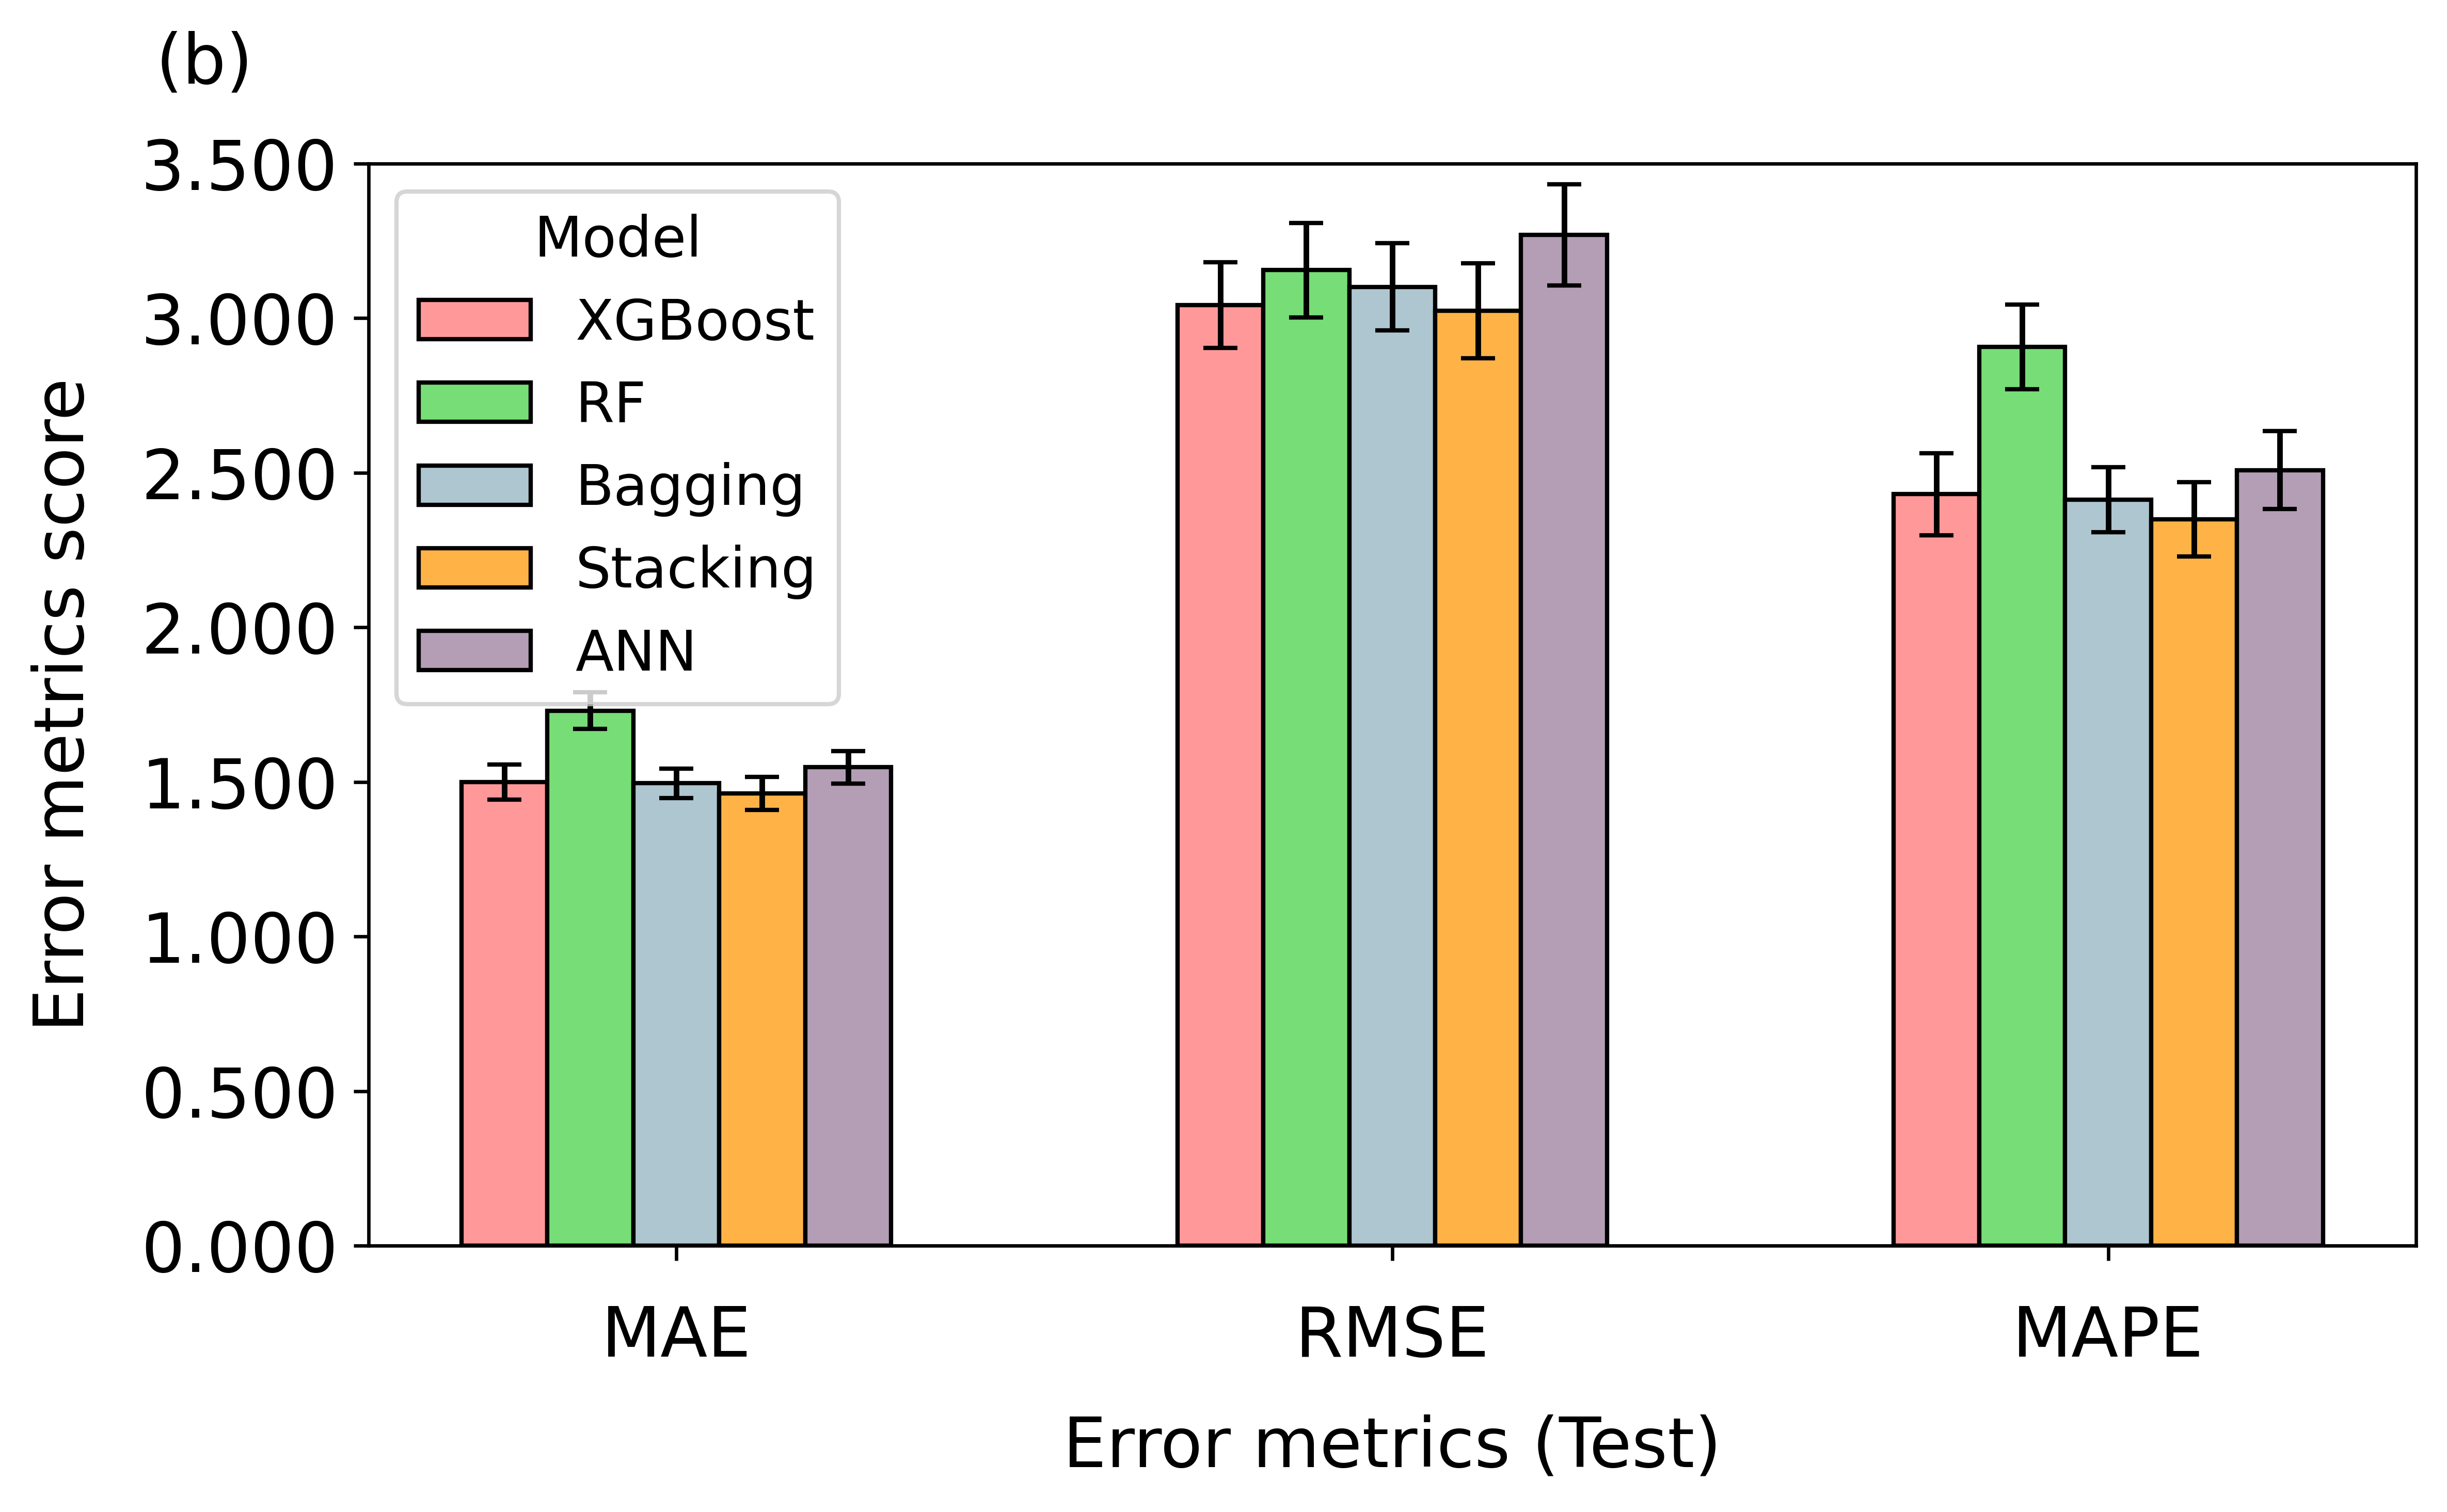

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = 'confidence interval.xlsx'
df = pd.read_excel(file_path)

metrics = ["MAE", "RMSE", "MAPE"]
colors = [
    "#FF9999",  # pastel red
    "#77DD77",   # pastel green
    "#AEC6CF",  # pastel blue
    "#FFB347",  # pastel orange
    "#B39EB5",  # pastel purple

]

num_models = len(df["Model"])
num_metrics = len(metrics)

x = np.arange(num_metrics)
width = 0.12

plt.figure(figsize=(8, 5),dpi=600)

# ---- store bar handles for legend ----
legend_handles = []

for i in range(num_models):

    model = df['Model'][i]

    means = [
        df[f"Mean {metrics[0]} Score"][i],
        df[f"Mean {metrics[1]} Score"][i],
        df[f"Mean {metrics[2]} Score"][i],
    ]

    lowers = [
        means[0] - df[f"Lower {metrics[0]} Score"][i],
        means[1] - df[f"Lower {metrics[1]} Score"][i],
        means[2] - df[f"Lower {metrics[2]} Score"][i],
    ]

    uppers = [
        df[f"Upper {metrics[0]} Score"][i] - means[0],
        df[f"Upper {metrics[1]} Score"][i] - means[1],
        df[f"Upper {metrics[2]} Score"][i] - means[2],
    ]

    # ----- Plot bars -----
    bar_pos = x + (i - num_models/2)*width + width/2
    bars = plt.bar(
        bar_pos,
        means,
        width,
        color=colors[i],
        edgecolor='black',
        zorder=2
    )

    # Save only one bar handle for legend
    legend_handles.append(bars[0])

    # ----- Error bars -----
    plt.errorbar(
        bar_pos,
        means,
        yerr=[lowers, uppers],
        fmt='none',
        ecolor='black',
        capsize=4,
        linewidth=1.3,
        zorder=3
    )

# ----- LABELS -----
plt.xticks(x, metrics, fontsize=16, color='black', rotation=0)
plt.tick_params(axis='x', pad=10)
plt.yticks(fontsize=16, color='black')
plt.ylabel("Error metrics score", fontsize=16, labelpad=10)
plt.xlabel("Error metrics (Test)", fontsize=16, labelpad=10)
plt.title("(b)", fontsize=16, x=-0.08, y=1.05)

# Set y-axis limit
plt.ylim(0.000, 3.500)

# Format y-axis ticks to show 3 decimals
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))


plt.legend(
    legend_handles,
    df["Model"],
    title="Model",
    fontsize=13,
    title_fontsize=13,
    loc='upper left'
)

plt.tight_layout()
plt.savefig("MAE_RMSE_MAPE_single_plot.png")
plt.show()